# Credit_Scoring_System

### Libraries 

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Dataset load

In [3]:
df = pd.read_csv('german_credit_data_updated.csv')

In [4]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


### EDA 

In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
df.head(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,2


In [7]:
df.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Credit Risk           0
dtype: int64

In [8]:
df.shape

(954, 10)

In [9]:
df.describe()

,Age,Job,Credit amount,Duration,Credit Risk
count,954.000000,954.000000,954.000000,954.000000,954.000000
mean,35.501048,1.909853,3279.112159,20.780922,1.302935
std,11.379668,0.649681,2853.315158,12.046483,0.459768
min,19.000000,0.000000,250.000000,4.000000,1.000000
25%,27.000000,2.000000,1360.250000,12.000000,1.000000
50%,33.000000,2.000000,2302.500000,18.000000,1.000000
75%,42.000000,2.000000,3975.250000,24.000000,2.000000
max,75.000000,3.000000,18424.000000,72.000000,2.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               954 non-null    int64 
 1   Sex               954 non-null    object
 2   Job               954 non-null    int64 
 3   Housing           954 non-null    object
 4   Saving accounts   779 non-null    object
 5   Checking account  576 non-null    object
 6   Credit amount     954 non-null    int64 
 7   Duration          954 non-null    int64 
 8   Purpose           954 non-null    object
 9   Credit Risk       954 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 74.7+ KB


### Handel Missing 

In [11]:
df['Saving accounts'].fillna('unknown', inplace=True)
df['Checking account'].fillna('unknown', inplace=True)
print(df.isnull().sum())

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Credit Risk         0
dtype: int64


In [12]:
### 

In [13]:
# Convert Credit Risk: 1 = Good (0), 2 = Bad (1)
df['Credit Risk'] = df['Credit Risk'].map({1: 0, 2: 1})

### Catagorical to NUmerical

In [14]:
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,1,2,1,4,0,1169,6,5,0
1,22,0,2,1,0,1,5951,48,5,1
2,49,1,1,1,0,3,2096,12,3,0
3,45,1,2,0,0,0,7882,42,4,0
4,53,1,2,0,0,0,4870,24,1,1
...,...,...,...,...,...,...,...,...,...,...
949,31,1,2,1,1,3,3621,24,5,1
950,40,1,0,1,0,1,3590,18,0,0
951,24,1,2,1,0,0,2145,36,0,1
952,28,0,2,2,2,1,4113,24,1,1


###  Target Distribution

Credit Risk
0    665
1    289
Name: count, dtype: int64


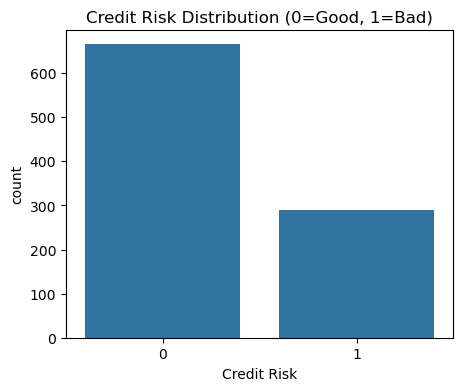

In [16]:
# Check class balance (Good vs Bad credit)
print(df['Credit Risk'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='Credit Risk', data=df)
plt.title('Credit Risk Distribution (0=Good, 1=Bad)')
plt.show()

### Numeric Features vs Target

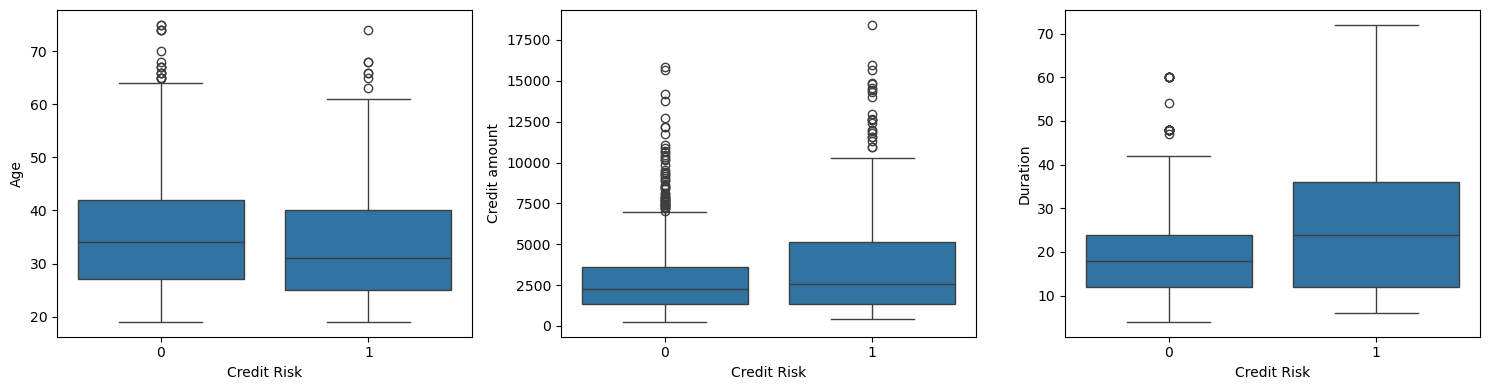

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(x='Credit Risk', y='Age', data=df, ax=axes[0])
sns.boxplot(x='Credit Risk', y='Credit amount', data=df, ax=axes[1])
sns.boxplot(x='Credit Risk', y='Duration', data=df, ax=axes[2])

plt.tight_layout()
plt.show()

### Train Test Split 

In [18]:
# Features aur target alag karo
X = df.drop(columns=['Credit Risk'])
y = df['Credit Risk']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (763, 9)
X_test:  (191, 9)


### Scalling 

In [19]:
# Numeric columns scale karo
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Scaling done!")

✅ Scaling done!


## Model_Training 

### Logictic Regression

In [20]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


### Random_Forest

In [21]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

print("✅ Random Forest trained!")

✅ Random Forest trained!


## Accuracy 

In [22]:
# Quick comparison
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Logistic Regression Accuracy : {lr_acc:.2f}")
print(f"Random Forest Accuracy       : {rf_acc:.2f}")

Logistic Regression Accuracy : 0.74
Random Forest Accuracy       : 0.75


## Model_Evaluation

=== Logistic Regression ===
Accuracy  : 0.74
Precision : 0.55
Recall    : 0.78
F1 Score  : 0.64
ROC-AUC   : 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.72      0.79       133
           1       0.55      0.78      0.64        58

    accuracy                           0.74       191
   macro avg       0.71      0.75      0.72       191
weighted avg       0.78      0.74      0.75       191



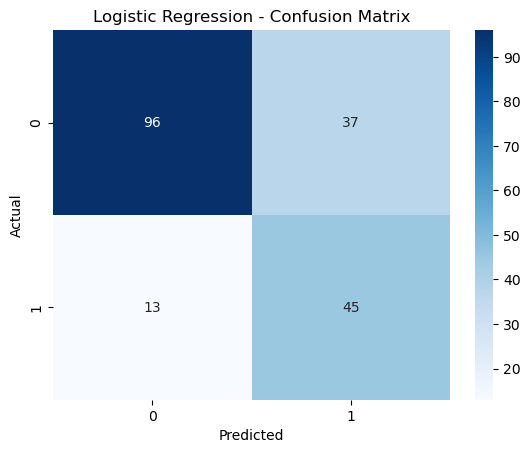

In [23]:
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy  : {accuracy_score(y_test, lr_pred):.2f}")
print(f"Precision : {precision_score(y_test, lr_pred):.2f}")
print(f"Recall    : {recall_score(y_test, lr_pred):.2f}")
print(f"F1 Score  : {f1_score(y_test, lr_pred):.2f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, lr_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

=== Random Forest ===
Accuracy  : 0.75
Precision : 0.63
Recall    : 0.41
F1 Score  : 0.50
ROC-AUC   : 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       133
           1       0.63      0.41      0.50        58

    accuracy                           0.75       191
   macro avg       0.70      0.65      0.67       191
weighted avg       0.73      0.75      0.73       191



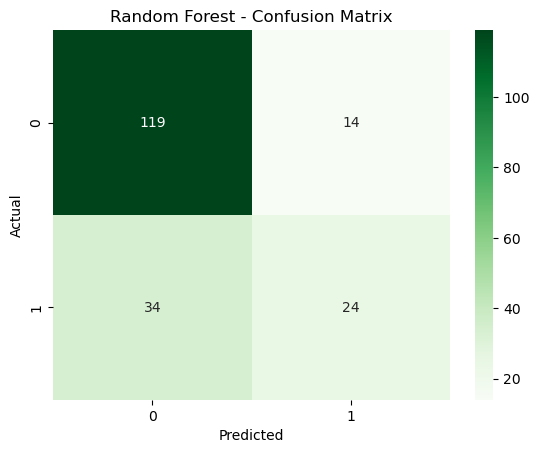

In [24]:
rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, rf_pred):.2f}")
print(f"Precision : {precision_score(y_test, rf_pred):.2f}")
print(f"Recall    : {recall_score(y_test, rf_pred):.2f}")
print(f"F1 Score  : {f1_score(y_test, rf_pred):.2f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature Importance 

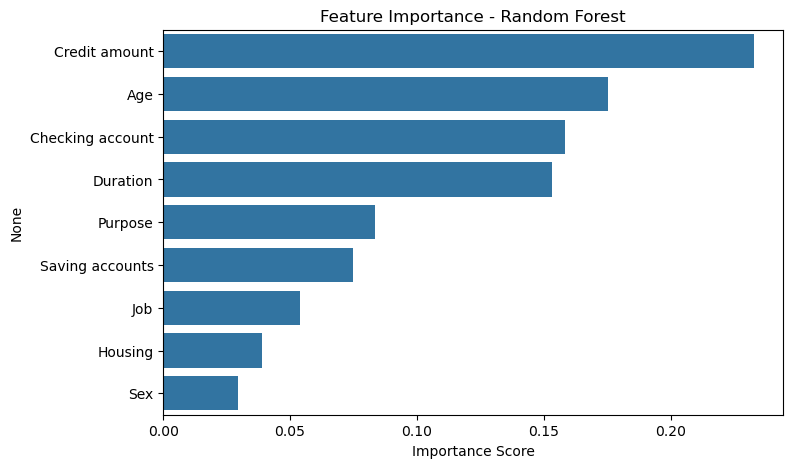


Feature Importance Ranking:
1. Credit amount        0.2328
2. Age                  0.1753
3. Checking account     0.1583
4. Duration             0.1531
5. Purpose              0.0834
6. Saving accounts      0.0749
7. Job                  0.0540
8. Housing              0.0388
9. Sex                  0.0294


In [25]:
# Random Forest se feature importance nikalo
feature_names = df.drop(columns=['Credit Risk']).columns

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

# Table format mein bhi dekho
print("\nFeature Importance Ranking:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]:<20} {importances[idx]:.4f}")

## Final Prediction 

In [34]:
def predict_credit_risk(age, sex, job, housing, saving_accounts,
                         checking_account, credit_amount, duration, purpose):

    encoded = [[
        age,
        mappings['Sex'][sex],
        job,
        mappings['Housing'][housing],
        mappings['Saving accounts'][saving_accounts],
        mappings['Checking account'][checking_account],
        credit_amount,
        duration,
        mappings['Purpose'][purpose]
    ]]

    input_scaled = scaler.transform(encoded)
    prediction   = lr_model.predict(input_scaled)[0]
    probability  = lr_model.predict_proba(input_scaled)[0]

    risk = "🔴 BAD Credit Risk" if prediction == 1 else "🟢 GOOD Credit Risk"
    print(f"Prediction       : {risk}")
    print(f"Good Probability : {probability[0]:.2f}")
    print(f"Bad  Probability : {probability[1]:.2f}")

# Test
predict_credit_risk(
    age=45,
    sex='male',
    job=3,
    housing='own',
    saving_accounts='rich',
    checking_account='rich',
    credit_amount=1000,
    duration=6,
    purpose='car'
)

Prediction       : 🟢 GOOD Credit Risk
Good Probability : 0.84
Bad  Probability : 0.16


## Test 

predict_credit_risk(
    age=35,
    sex='male',
    job=2,
    housing='own',
    saving_accounts='little',
    checking_account='moderate',
    credit_amount=3000,
    duration=12,
    purpose='car'
)

## Save Model 

In [37]:
import pickle

# Save model, scaler, mappings
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)

print("✅ Model, Scaler, Mappings saved!")

✅ Model, Scaler, Mappings saved!
